## Preparing data + Cleanup

## Installing Dependencies
%pip install polars
%pip install matplotlib

In [38]:
import polars as pl
import datetime as dt

# Read the csv file into a Polars DataFrame
df = pl.read_csv("indian_roads_dataset.csv", try_parse_dates=True)

# Convert 'day_of_week' column to have 1 for weekdays and 0 for weekends
df = df.with_columns(pl.when(pl.col("day_of_week").is_in(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]))
                .then(0)
                .otherwise(1)
                .alias("day_of_week"))

# Select 'accident_id' and 'day_of_week' columns and print it
# accident_day_column = df.select(["accident_id", "day_of_week"])
# print(accident_day_column)

# Remove 'None' from the 'festival' column
df = df.with_columns(pl.when(pl.col("festival") == "None")
                .then(None)
                .otherwise(pl.col("festival"))
                .alias("festival"))

# Select 'festival', 'accident_id' column and print it
#festival_column = df.select(["festival", "accident_id"])
#print(festival_column)
print(df.head())



shape: (5, 24)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬──────────┬───────────┐
│ accident_ ┆ city      ┆ state     ┆ latitude  ┆ … ┆ casualtie ┆ is_peak_h ┆ festival ┆ risk_scor │
│ id        ┆ ---       ┆ ---       ┆ ---       ┆   ┆ s         ┆ our       ┆ ---      ┆ e         │
│ ---       ┆ str       ┆ str       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ str      ┆ ---       │
│ i64       ┆           ┆           ┆           ┆   ┆ i64       ┆ i64       ┆          ┆ f64       │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪══════════╪═══════════╡
│ 0         ┆ Pune      ┆ Maharasht ┆ 18.680827 ┆ … ┆ 2         ┆ 0         ┆ null     ┆ 0.85      │
│           ┆           ┆ ra        ┆           ┆   ┆           ┆           ┆          ┆           │
│ 1         ┆ Mumbai    ┆ Maharasht ┆ 18.817732 ┆ … ┆ 3         ┆ 0         ┆ null     ┆ 0.1       │
│           ┆           ┆ ra        ┆           ┆   ┆           ┆           

In [43]:
# Get the total accidents that happened on highway due to overspeeding.
overspeeding_accidents = df.filter((pl.col("road_type") == "highway") & (pl.col("cause") == "overspeeding"))
total_overspeeding_accidents = overspeeding_accidents.shape[0]
print(f"Total accidents on highway due to overspeeding: {total_overspeeding_accidents}")

Total accidents on highway due to overspeeding: 1302


## Total number of accidents happened in all the states

shape: (7, 2)
┌─────────────┬─────────────────┐
│ state       ┆ total_accidents │
│ ---         ┆ ---             │
│ str         ┆ u32             │
╞═════════════╪═════════════════╡
│ Maharashtra ┆ 5009            │
│ Punjab      ┆ 2577            │
│ Tamil Nadu  ┆ 2575            │
│ West Bengal ┆ 2559            │
│ Karnataka   ┆ 2438            │
│ Delhi       ┆ 2433            │
│ Telangana   ┆ 2409            │
└─────────────┴─────────────────┘


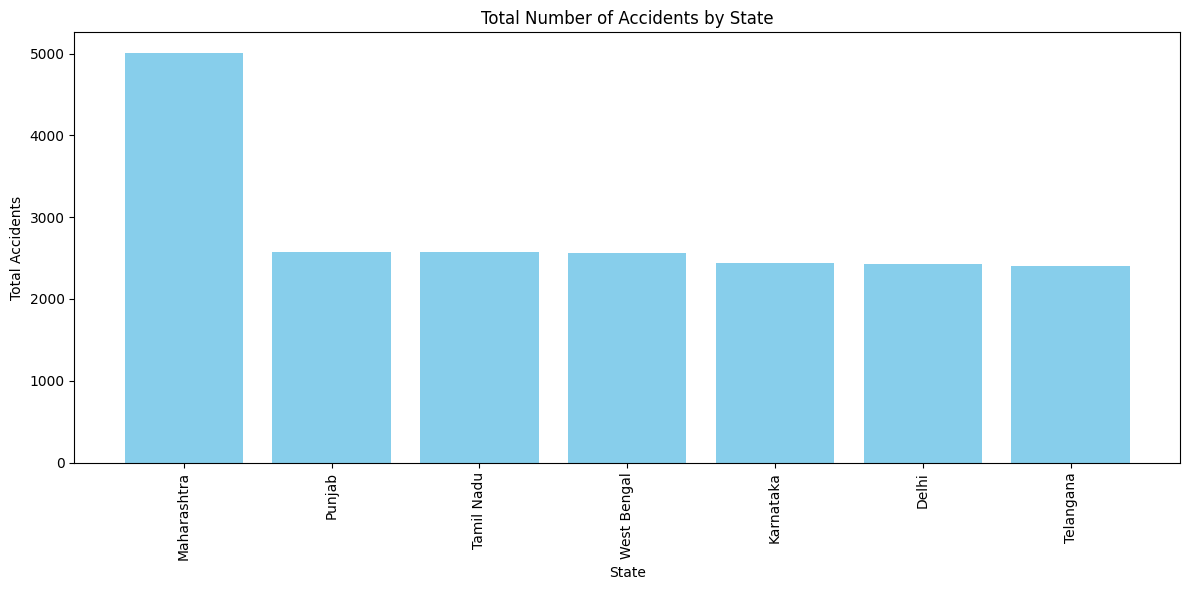

In [34]:
# Get the total number of accident happened in all the states and plot it in a bar graph
state_accidents = df.group_by("state").agg(pl.count("accident_id").alias("total_accidents"))
state_accidents = state_accidents.sort("total_accidents", descending=True)
print(state_accidents)

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.bar(state_accidents["state"], state_accidents["total_accidents"], color='skyblue')
plt.xlabel("State")
plt.ylabel("Total Accidents")
plt.title("Total Number of Accidents by State")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [30]:
# Get the total number of accident happened in the state of Maharashtra
maharashtra_accidents = df.filter(pl.col("state") == "Maharashtra").shape[0]
print(f"Total number of accidents in Maharashtra: {maharashtra_accidents}")

Total number of accidents in Maharashtra: 5009


## Distribution of Accidents by Day of the Week

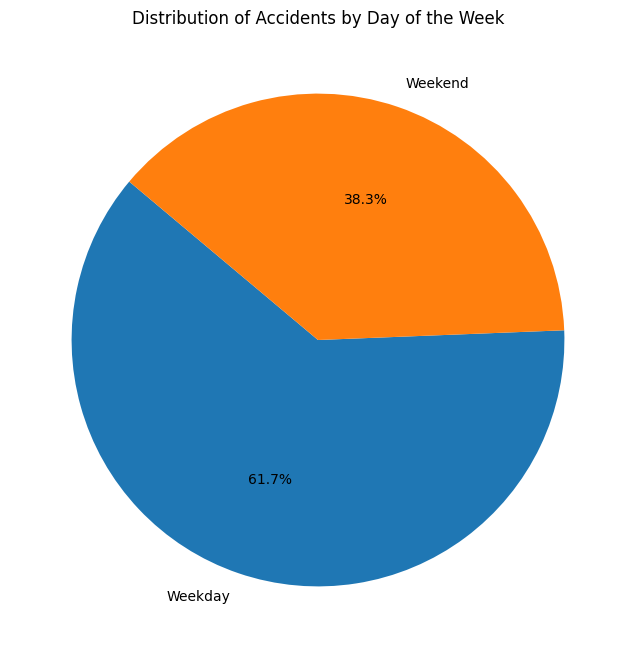

In [9]:
# show a pie chart of the distribution of accidents by day of the week
import matplotlib.pyplot as plt

# Count the number of accidents for each day of the week
accidents_by_day = df.group_by("day_of_week").agg(
	pl.count("accident_id").alias("accident_count")
).sort("day_of_week")


# How can I change the labels of the pie chart to show "Weekday" and "Weekend" instead of 0 and 1?
# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(
	accidents_by_day["accident_count"].to_list(),
	labels=["Weekday" if x == 0 else "Weekend" for x in accidents_by_day["day_of_week"].to_list()],
	autopct="%1.1f%%",
	startangle=140,
)
plt.title("Distribution of Accidents by Day of the Week")
plt.show()

## Number of accidents for each festival

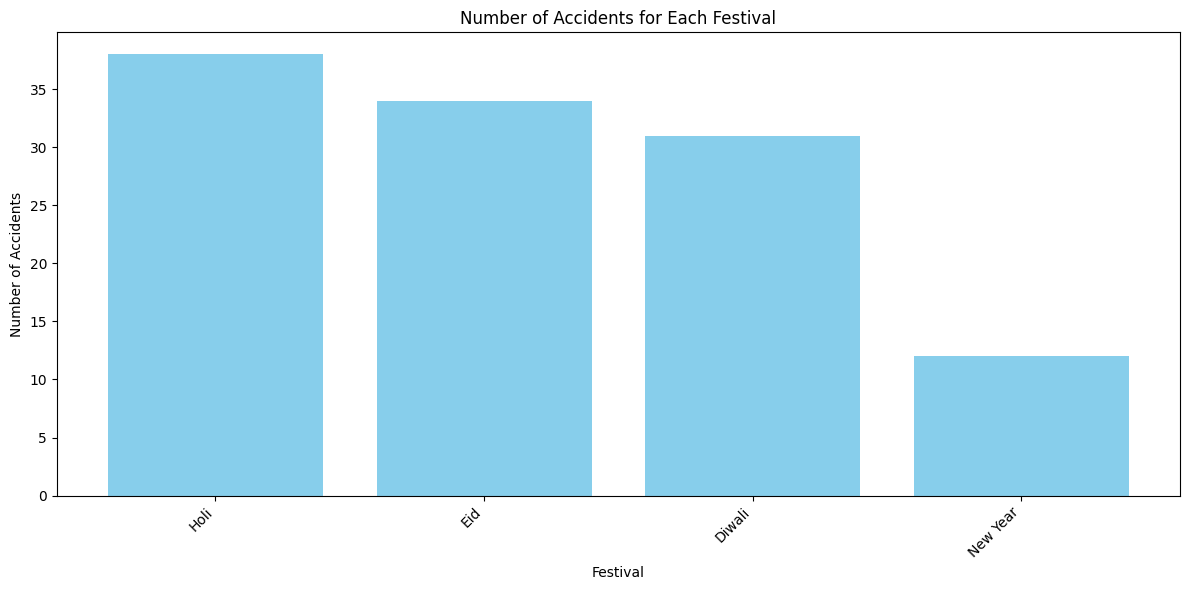

In [11]:
# Generate a bar chart showing the number of accidents for each festival
# Count the number of accidents for each festival
accidents_by_festival = df.group_by("festival").agg(
    pl.count("accident_id").alias("accident_count")
).sort("accident_count", descending=True)
# Plot the bar chart
plt.figure(figsize=(12, 6))
plt.bar(
    accidents_by_festival["festival"].to_list(),
    accidents_by_festival["accident_count"].to_list(),
    color="skyblue",
)
plt.xlabel("Festival")
plt.ylabel("Number of Accidents")
plt.title("Number of Accidents for Each Festival")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()